In [ ]:
# .ipynb template adapted from https://piazza.com/class/mgb5d1q2aup2n1/post/182

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder
!ls -la

In [ ]:
!nvidia-smi
!python -V

In [ ]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
!sudo apt-get update -y
!sudo apt-get install -y python3.9 python3.9-dev python3.9-distutils python3.9-venv
!curl -sS https://bootstrap.pypa.io/get-pip.py | sudo python3.9
!sudo update-alternatives --install /usr/bin/python python /usr/bin/python3.9 1
!sudo update-alternatives --install /usr/bin/python python /usr/bin/python3 2
!sudo update-alternatives --config python # select python3.9 (hit the number corresponding to python3.9 and press enter)

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,201 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,508 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/m

In [ ]:
!python3.9 -m venv /content/py39
!source /content/py39/bin/activate && python --version

Python 3.9.25


In [ ]:
!source /content/py39/bin/activate && pip install \
    torch==1.13.1 hydra-core==1.3.2 hydra-submitit-launcher==1.1.5 \
    hydra-optuna-sweeper==1.2.0 numpy==1.25.0 scipy==1.11.1 numba==0.58.1 \
    scikit-learn==1.3.2 g2p_en==2.1.0 edit_distance==1.0.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.4/887.4 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 77.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 46.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 110.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 118.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 113.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 77.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 77.2 MB/s et

In [ ]:
!source /content/py39/bin/activate && pip install -e .

Obtaining file:///content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.1/893.1 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.4/92.4 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 24.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 18.2 MB/s eta 0:00:00
  Building editable for neural_decoder (pyproject.toml) ... done
  Created wheel for neural_decoder: filenam

In [ ]:
!source /content/py39/bin/activate && \
    cd /content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder && \
    python ./scripts/train_model.py

/content/py39/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder/src/neural_decoder/augmentations.py:91: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:895.)
  return self.conv(input, weight=self.weight, groups=self.groups, padding="same")
/content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder/src/neural_decoder/cr_ctc_neural_decoder_trainer.py:289: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.ten

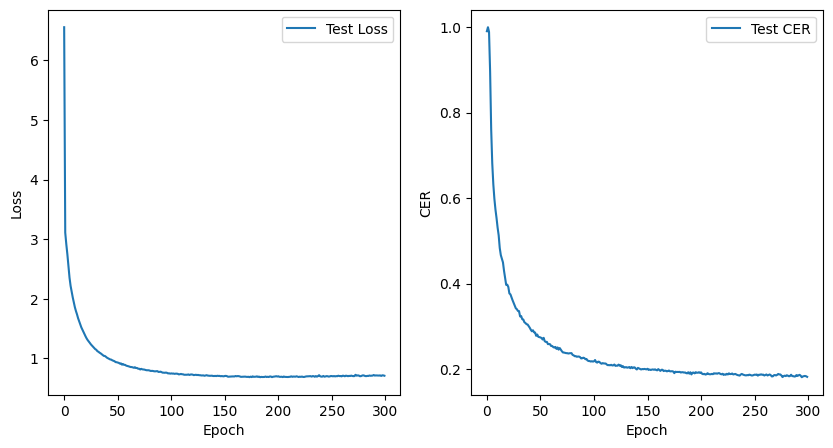

Test Loss: [6.55514417 3.11032786 2.91576059 2.74585179 2.54669244 2.35546984
 2.21800872 2.12007386 2.02543068 1.9432666  1.85952732 1.79493441
 1.73948465 1.6751882  1.62341826 1.57421698 1.5230623  1.48364707
 1.44483975 1.40104703 1.36980683 1.33548083 1.30730547 1.28514235
 1.26023906 1.23554053 1.21568135 1.19811589 1.17515237 1.15716839
 1.14612893 1.12305423 1.11288548 1.09791374 1.08707769 1.07324192
 1.06167855 1.04389109 1.04168047 1.02847501 1.01278993 1.00355898
 0.99396167 0.98392289 0.980471   0.96874932 0.96134227 0.9545205
 0.9395959  0.93728406 0.93229403 0.92637198 0.91338376 0.91782652
 0.89698274 0.90606935 0.89389706 0.89214557 0.87928901 0.87453168
 0.86965193 0.86302492 0.85711799 0.85612338 0.85153948 0.84426641
 0.85345112 0.83994607 0.8414135  0.82864993 0.82864945 0.81568636
 0.82608448 0.81789017 0.81523296 0.81337336 0.80712134 0.80292947
 0.80232559 0.80240897 0.79666771 0.79014676 0.79289511 0.79025786
 0.78560243 0.78429447 0.78647    0.78849615 0.77465

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

def load_pickle_file(filename):
    """Loads data from a pickle file."""
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        return data
    except Exception as e:
        print(f"Error loading pickle file: {e}")
        return None

# Example usage:
pickle_filename = '/content/drive/MyDrive/ECEC243A/FinalProject/logs/speechBaseline4/trainingStats' # MY COLAB DIRECTORY. REPLACE AS NEEDED
loaded_data = load_pickle_file(pickle_filename)

if loaded_data is not None:
    test_loss = loaded_data['testLoss']
    test_cer = loaded_data['testCER']
    # Plot the loss and cer over batch
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(test_cer, label='Test CER')
    plt.xlabel('Epoch')
    plt.ylabel('CER')
    plt.legend()
    plt.show()
    # Print the loaded data
    print("Test Loss:", test_loss)
    print("Test CER:", test_cer)
    print("Data loaded successfully:")
    # print(loaded_data)